In [1]:
import os
import time
import psutil
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize  # ✅ Removed RobustScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

Using: cuda


In [3]:
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))
print("Shape:", df.shape)

Shape: (427625, 25)


In [4]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.cnn_fc = nn.Linear(64, hidden_dim)

        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        cnn_in = x.unsqueeze(1)
        cnn_out = self.conv(cnn_in).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        lstm_in = x.unsqueeze(-1)
        lstm_out, _ = self.lstm(lstm_in)
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        combined = torch.cat([cnn_feat, lstm_feat], dim=1)
        gate = self.gate(combined)
        fused = gate * cnn_feat + (1 - gate) * lstm_feat

        logits = self.classifier(fused)
        return logits

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)

        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [7]:
def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            prob = torch.softmax(logits, dim=1)

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs

# Borderline SMOTE

In [8]:
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # ----------------- BEFORE SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - Class Distribution BEFORE SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution BEFORE SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- BORDERLINE SMOTE -----------------
    try:
        smote = BorderlineSMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ BorderlineSMOTE failed:", e)

    # ----------------- AFTER SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - Class Distribution AFTER SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution AFTER SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING (UPDATED) -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- DATA LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY PLOT -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} - Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} - ROC Curve")
    plt.legend()
    plt.show()

    # ----------------- PRECISION-RECALL CURVE -----------------
    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} - Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ----------------- PERFORMANCE STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f} seconds")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


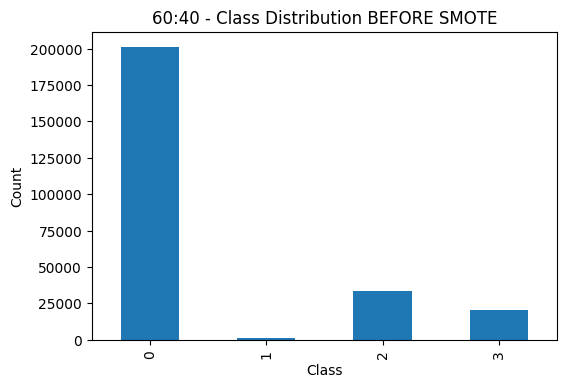

Train Distribution BEFORE SMOTE:
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


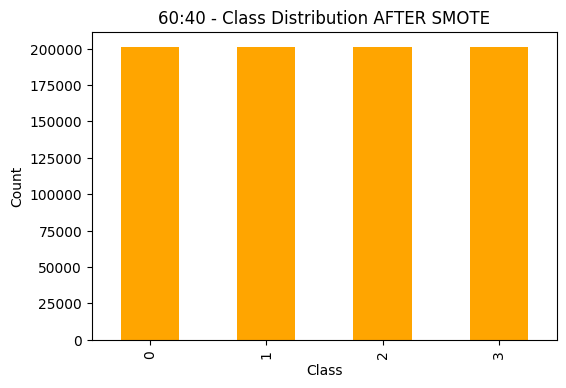

Train Distribution AFTER SMOTE:
0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1220, TrainAcc=0.9548, TestAcc=0.9731, ROC-AUC=0.9990
Epoch 2: Loss=0.0407, TrainAcc=0.9870, TestAcc=0.9753, ROC-AUC=0.9993
Epoch 3: Loss=0.0314, TrainAcc=0.9903, TestAcc=0.9816, ROC-AUC=0.9995
Epoch 4: Loss=0.0270, TrainAcc=0.9917, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 5: Loss=0.0244, TrainAcc=0.9925, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 6: Loss=0.0226, TrainAcc=0.9931, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 7: Loss=0.0213, TrainAcc=0.9935, TestAcc=0.9804, ROC-AUC=0.9995
Epoch 8: Loss=0.0200, TrainAcc=0.9939, TestAcc=0.9848, ROC-AUC=0.9994
Epoch 9: Loss=0.0193, TrainAcc=0.9941, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 10: Loss=0.0188, TrainAcc=0.9942, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 11: Loss=0.0183, TrainAcc=0.9944, TestAcc=0.9832, ROC-AUC=0.9995
Epoch 12: Loss=0.0182, TrainAcc=0.9944, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 13: Loss=0.0174, TrainAcc=0.9947, TestAcc=0.9

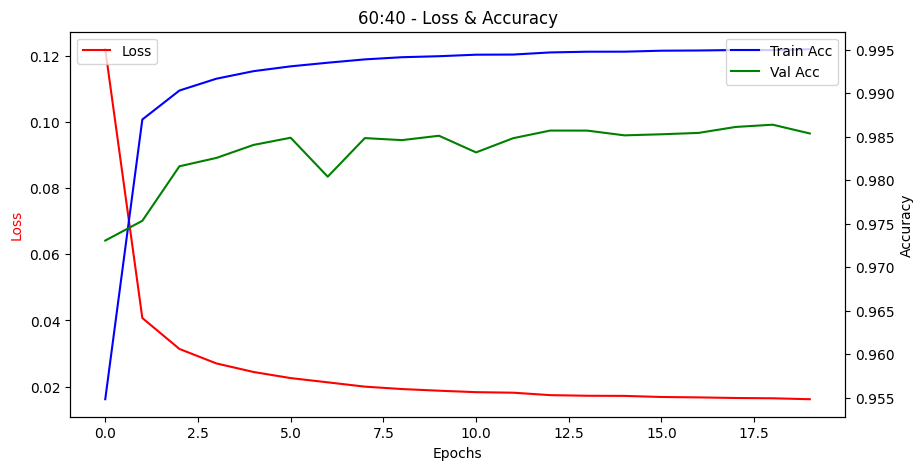

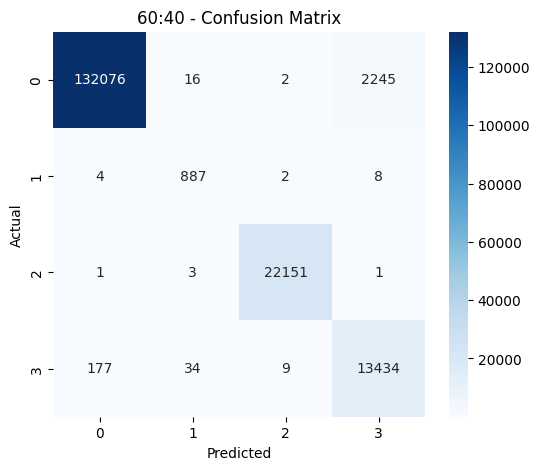


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.94      0.98      0.96       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.95      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



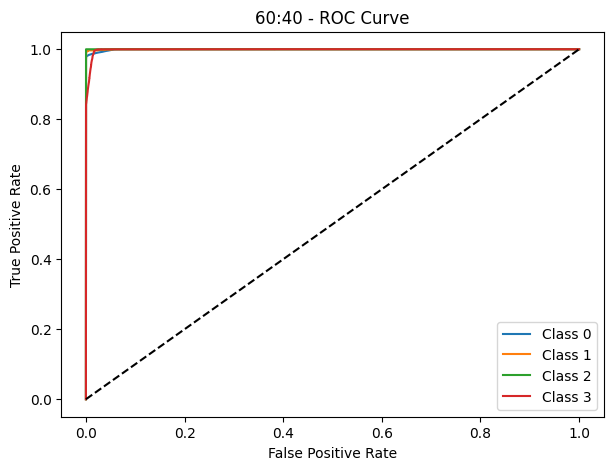

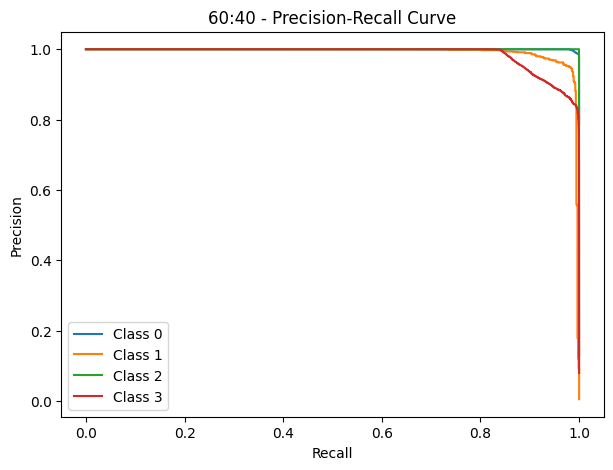


Runtime: 3285.26 seconds
RAM Used: 583.04 MB

========== 70:30 ==========


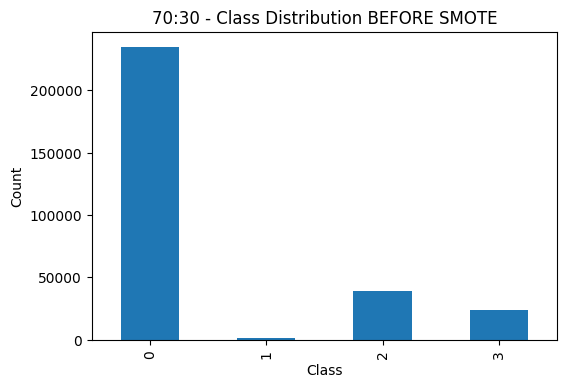

Train Distribution BEFORE SMOTE:
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


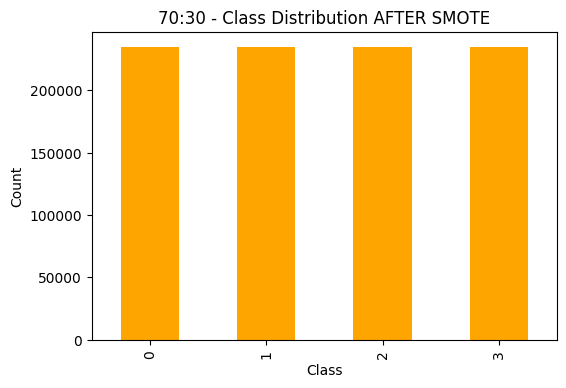

Train Distribution AFTER SMOTE:
0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.1388, TrainAcc=0.9486, TestAcc=0.9797, ROC-AUC=0.9990
Epoch 2: Loss=0.0489, TrainAcc=0.9843, TestAcc=0.9758, ROC-AUC=0.9991
Epoch 3: Loss=0.0365, TrainAcc=0.9885, TestAcc=0.9836, ROC-AUC=0.9993
Epoch 4: Loss=0.0298, TrainAcc=0.9907, TestAcc=0.9816, ROC-AUC=0.9993
Epoch 5: Loss=0.0263, TrainAcc=0.9919, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 6: Loss=0.0237, TrainAcc=0.9928, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 7: Loss=0.0220, TrainAcc=0.9933, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 8: Loss=0.0208, TrainAcc=0.9937, TestAcc=0.9848, ROC-AUC=0.9996
Epoch 9: Loss=0.0200, TrainAcc=0.9939, TestAcc=0.9823, ROC-AUC=0.9995
Epoch 10: Loss=0.0191, TrainAcc=0.9942, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 11: Loss=0.0188, TrainAcc=0.9943, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 12: Loss=0.0183, TrainAcc=0.9945, TestAcc=0.9863, ROC-AUC=0.9995
Epoch 13: Loss=0.0177, TrainAcc=0.9947, TestAcc=0.9

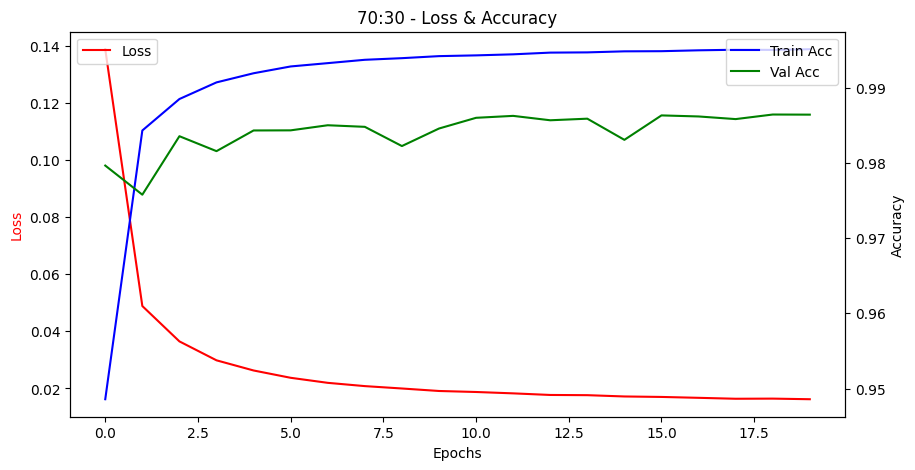

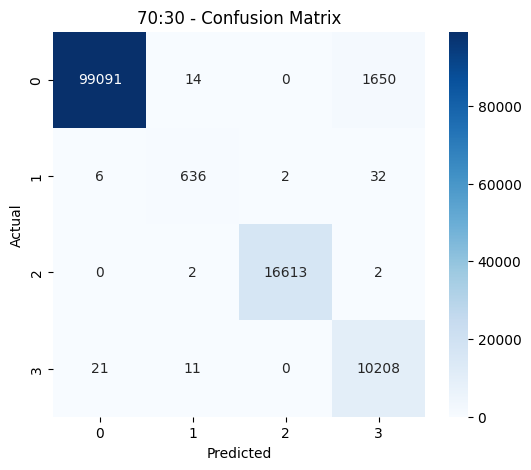


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.96      0.94      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.86      1.00      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.98      0.97    128288
weighted avg       0.99      0.99      0.99    128288



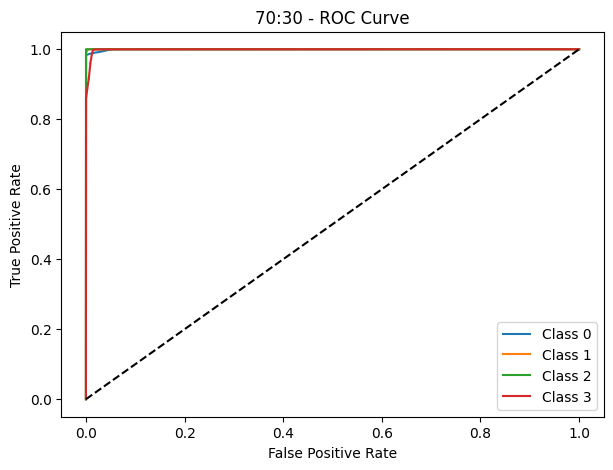

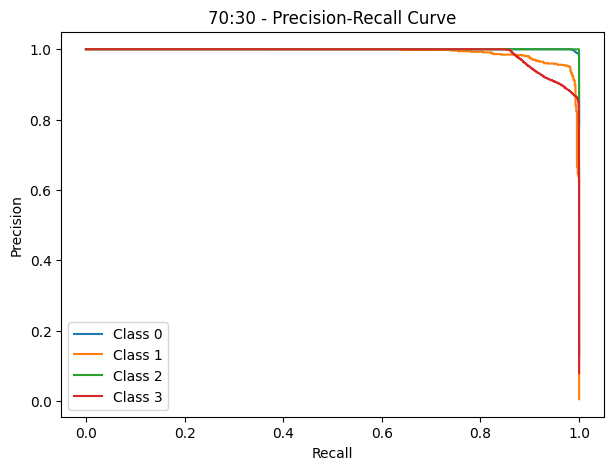


Runtime: 3705.35 seconds
RAM Used: 428.37 MB

========== 80:20 ==========


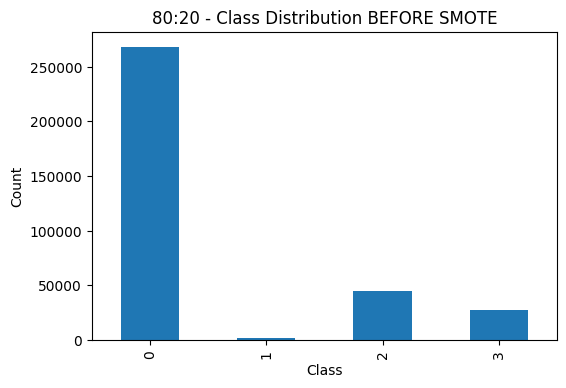

Train Distribution BEFORE SMOTE:
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


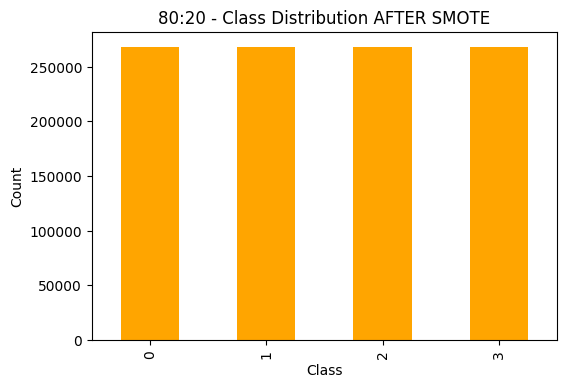

Train Distribution AFTER SMOTE:
0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.1217, TrainAcc=0.9546, TestAcc=0.9721, ROC-AUC=0.9991
Epoch 2: Loss=0.0390, TrainAcc=0.9877, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 3: Loss=0.0306, TrainAcc=0.9906, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 4: Loss=0.0265, TrainAcc=0.9920, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 5: Loss=0.0241, TrainAcc=0.9928, TestAcc=0.9849, ROC-AUC=0.9994
Epoch 6: Loss=0.0223, TrainAcc=0.9934, TestAcc=0.9860, ROC-AUC=0.9995
Epoch 7: Loss=0.0207, TrainAcc=0.9938, TestAcc=0.9831, ROC-AUC=0.9995
Epoch 8: Loss=0.0197, TrainAcc=0.9941, TestAcc=0.9820, ROC-AUC=0.9995
Epoch 9: Loss=0.0194, TrainAcc=0.9942, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 10: Loss=0.0187, TrainAcc=0.9945, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 11: Loss=0.0182, TrainAcc=0.9945, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 12: Loss=0.0176, TrainAcc=0.9947, TestAcc=0.9857, ROC-AUC=0.9996
Epoch 13: Loss=0.0172, TrainAcc=0.9948, TestAcc=0.9

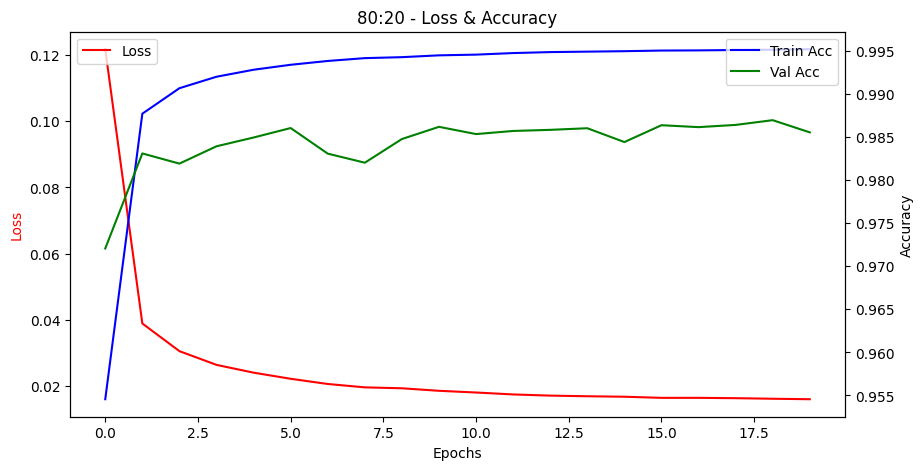

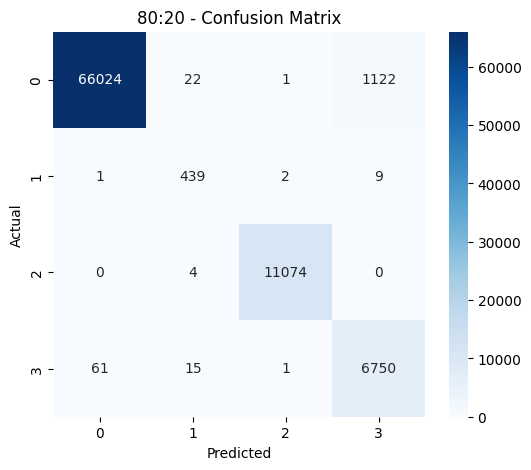


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.91      0.97      0.94       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



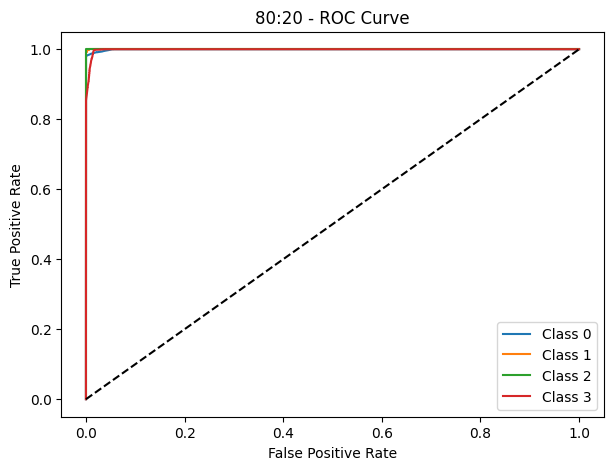

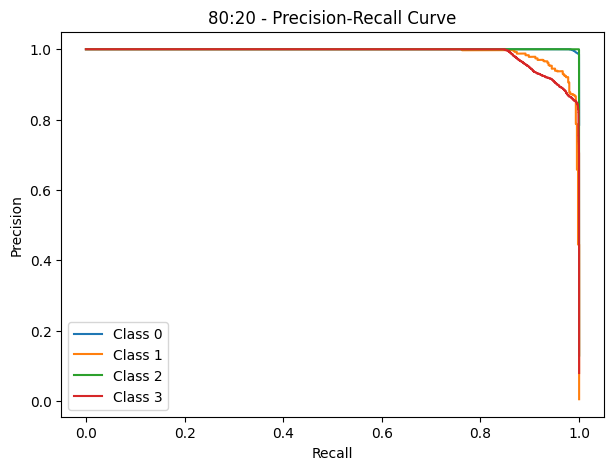


Runtime: 4167.68 seconds
RAM Used: 440.47 MB


In [9]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", 0.4)
run_split(df, "70:30", 0.3)
run_split(df, "80:20", 0.2)

# SMOTE

In [9]:
from imblearn.over_sampling import SMOTE

def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # ----------------- BEFORE SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - Class Distribution BEFORE SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution BEFORE SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SIMPLE SMOTE -----------------
    try:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ SMOTE failed:", e)

    # ----------------- AFTER SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - Class Distribution AFTER SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution AFTER SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING (UPDATED) -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- DATA LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY PLOT -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} - Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} - ROC Curve")
    plt.legend()
    plt.show()

    # ----------------- PRECISION-RECALL CURVE -----------------
    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} - Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ----------------- PERFORMANCE STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f} seconds")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


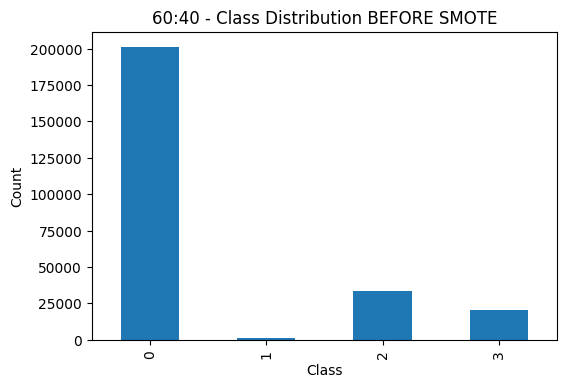

Train Distribution BEFORE SMOTE:
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


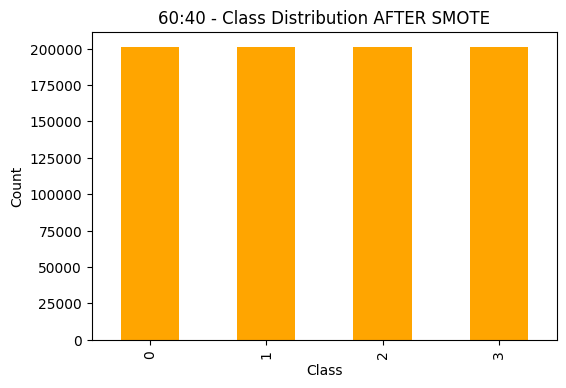

Train Distribution AFTER SMOTE:
0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1213, TrainAcc=0.9545, TestAcc=0.9732, ROC-AUC=0.9988
Epoch 2: Loss=0.0481, TrainAcc=0.9837, TestAcc=0.9749, ROC-AUC=0.9993
Epoch 3: Loss=0.0366, TrainAcc=0.9879, TestAcc=0.9780, ROC-AUC=0.9994
Epoch 4: Loss=0.0304, TrainAcc=0.9899, TestAcc=0.9822, ROC-AUC=0.9993
Epoch 5: Loss=0.0261, TrainAcc=0.9914, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 6: Loss=0.0243, TrainAcc=0.9920, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 7: Loss=0.0221, TrainAcc=0.9927, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 8: Loss=0.0205, TrainAcc=0.9932, TestAcc=0.9851, ROC-AUC=0.9994
Epoch 9: Loss=0.0194, TrainAcc=0.9936, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 10: Loss=0.0190, TrainAcc=0.9937, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 11: Loss=0.0182, TrainAcc=0.9940, TestAcc=0.9812, ROC-AUC=0.9995
Epoch 12: Loss=0.0179, TrainAcc=0.9942, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 13: Loss=0.0174, TrainAcc=0.9943, TestAcc=0.9

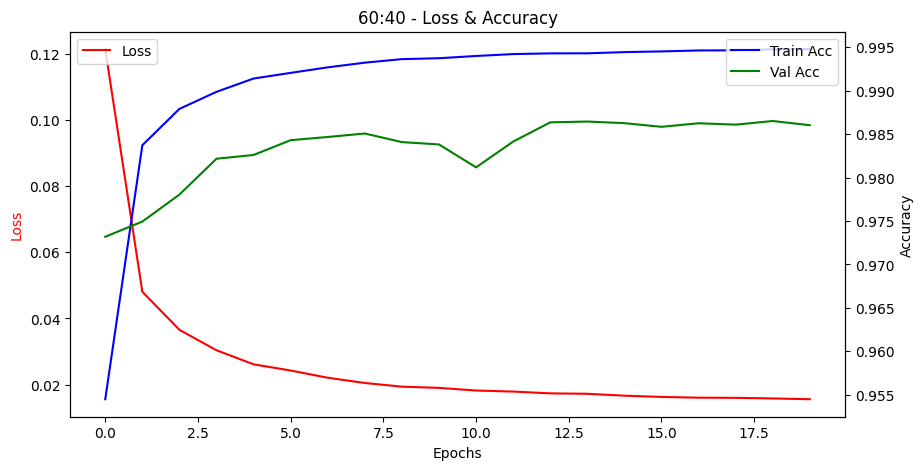

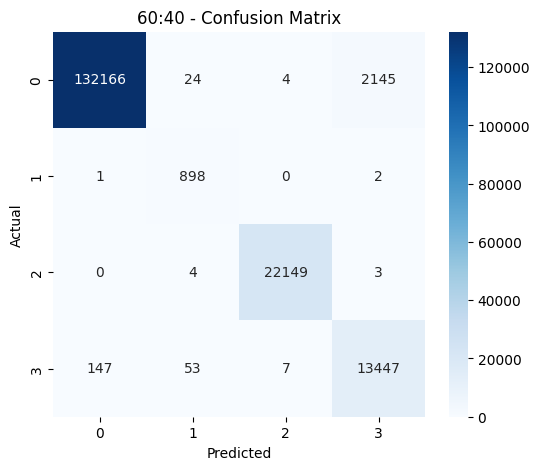


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.92      1.00      0.96       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



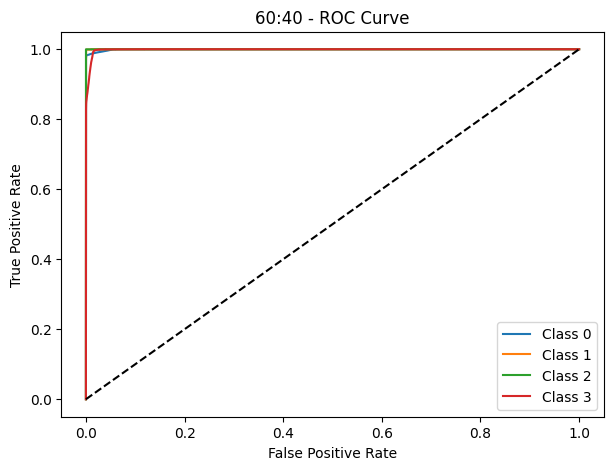

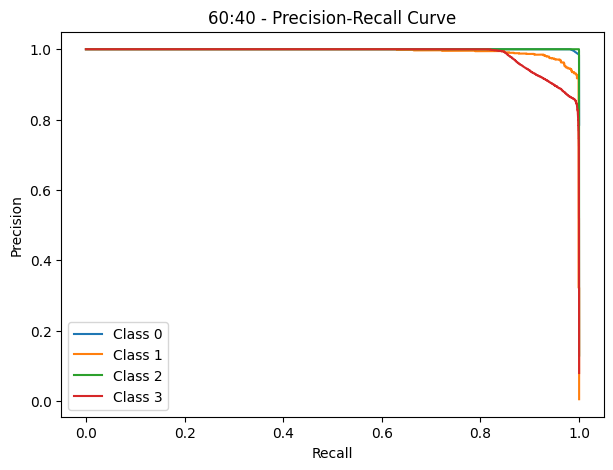


Runtime: 3769.66 seconds
RAM Used: 518.58 MB

========== 70:30 ==========


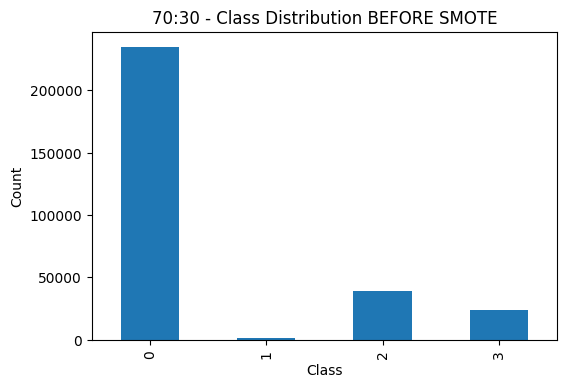

Train Distribution BEFORE SMOTE:
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


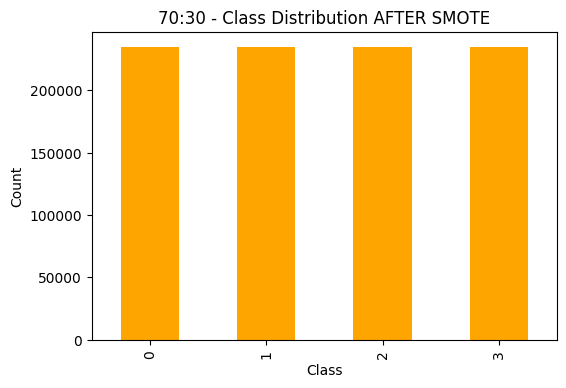

Train Distribution AFTER SMOTE:
0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.0895, TrainAcc=0.9666, TestAcc=0.9807, ROC-AUC=0.9991
Epoch 2: Loss=0.0310, TrainAcc=0.9895, TestAcc=0.9802, ROC-AUC=0.9994
Epoch 3: Loss=0.0254, TrainAcc=0.9915, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 4: Loss=0.0223, TrainAcc=0.9926, TestAcc=0.9837, ROC-AUC=0.9994
Epoch 5: Loss=0.0206, TrainAcc=0.9932, TestAcc=0.9749, ROC-AUC=0.9994
Epoch 6: Loss=0.0193, TrainAcc=0.9936, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 7: Loss=0.0186, TrainAcc=0.9938, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 8: Loss=0.0178, TrainAcc=0.9940, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 9: Loss=0.0172, TrainAcc=0.9942, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 10: Loss=0.0167, TrainAcc=0.9943, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 11: Loss=0.0164, TrainAcc=0.9945, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 12: Loss=0.0160, TrainAcc=0.9945, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 13: Loss=0.0159, TrainAcc=0.9947, TestAcc=0.9

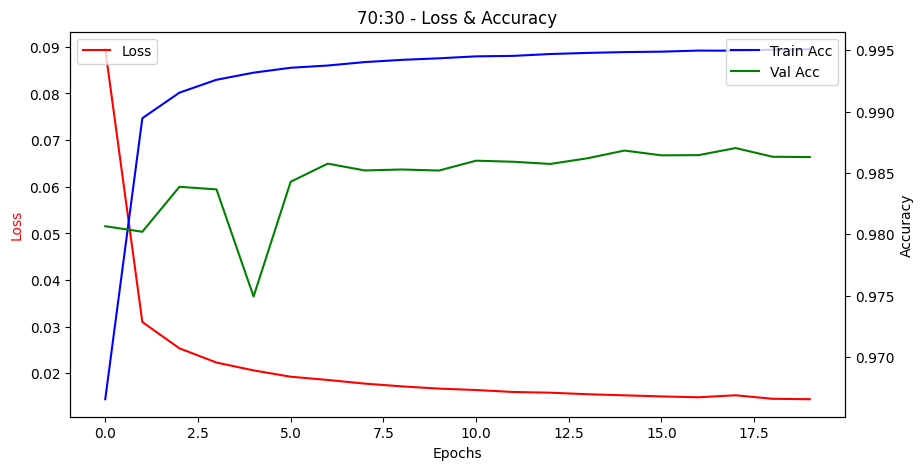

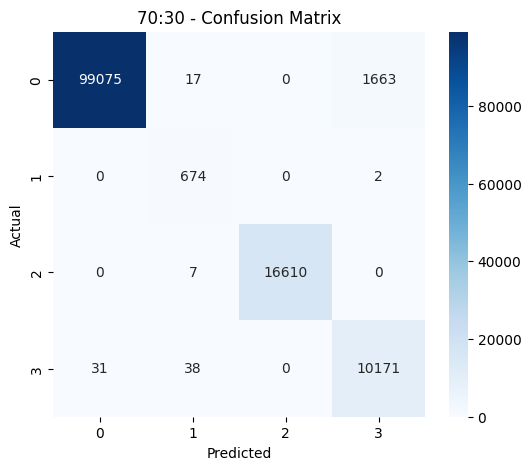


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.92      1.00      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



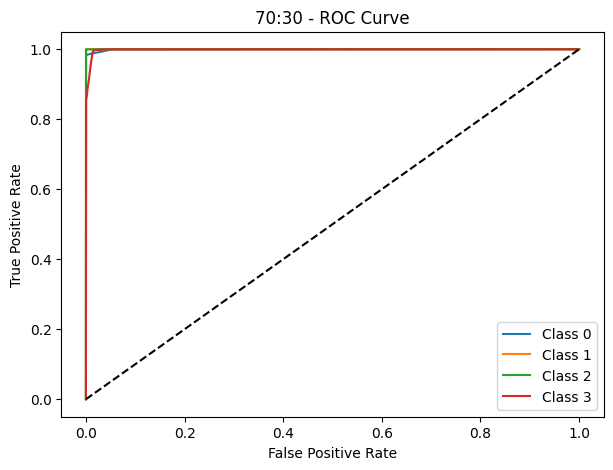

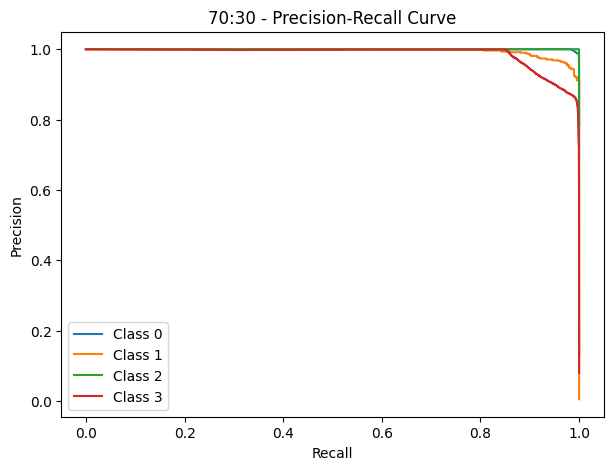


Runtime: 4271.45 seconds
RAM Used: 382.48 MB

========== 80:20 ==========


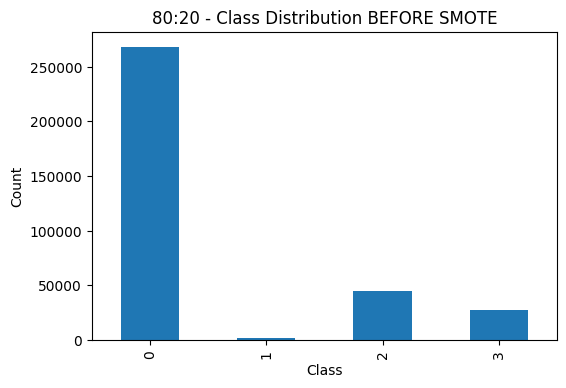

Train Distribution BEFORE SMOTE:
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


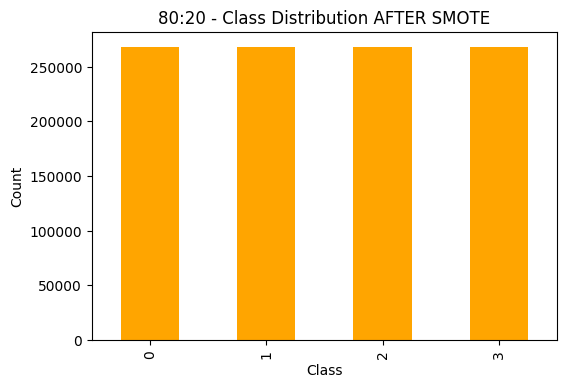

Train Distribution AFTER SMOTE:
0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.0927, TrainAcc=0.9653, TestAcc=0.9703, ROC-AUC=0.9991
Epoch 2: Loss=0.0304, TrainAcc=0.9897, TestAcc=0.9815, ROC-AUC=0.9994
Epoch 3: Loss=0.0243, TrainAcc=0.9920, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 4: Loss=0.0212, TrainAcc=0.9930, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 5: Loss=0.0197, TrainAcc=0.9934, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 6: Loss=0.0187, TrainAcc=0.9939, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 7: Loss=0.0178, TrainAcc=0.9941, TestAcc=0.9855, ROC-AUC=0.9996
Epoch 8: Loss=0.0174, TrainAcc=0.9942, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 9: Loss=0.0167, TrainAcc=0.9945, TestAcc=0.9857, ROC-AUC=0.9996
Epoch 10: Loss=0.0164, TrainAcc=0.9946, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 11: Loss=0.0161, TrainAcc=0.9947, TestAcc=0.9839, ROC-AUC=0.9996
Epoch 12: Loss=0.0157, TrainAcc=0.9947, TestAcc=0.9850, ROC-AUC=0.9996
Epoch 13: Loss=0.0156, TrainAcc=0.9948, TestAcc=0.9

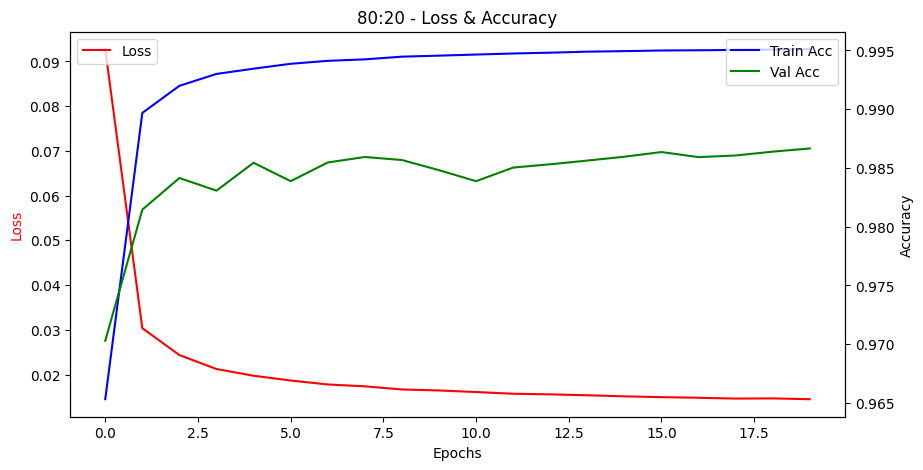

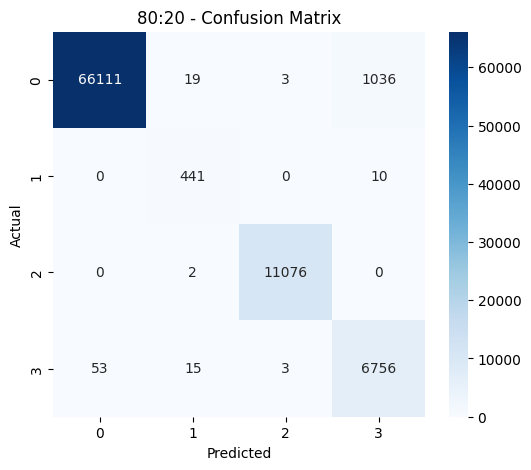


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.92      0.98      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.87      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.95      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



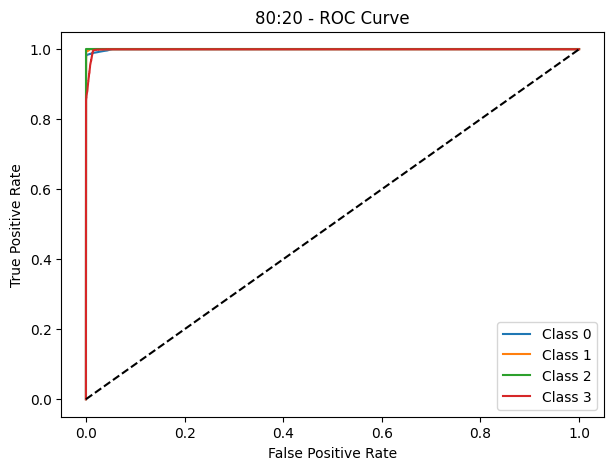

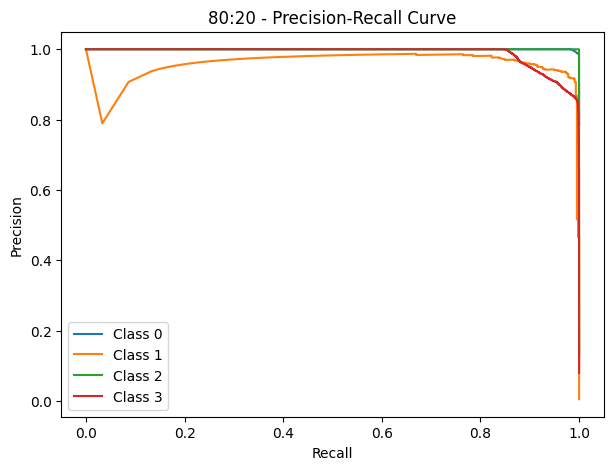


Runtime: 4419.03 seconds
RAM Used: 375.56 MB


In [10]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", 0.4)
run_split_smote(df, "70:30", 0.3)
run_split_smote(df, "80:20", 0.2)

# ADASYN

In [9]:
from imblearn.over_sampling import ADASYN

def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # ----------------- BEFORE SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - Class Distribution BEFORE SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution BEFORE SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- ADASYN -----------------
    try:
        adasyn = ADASYN(random_state=42)
        X_train, y_train = adasyn.fit_resample(X_train, y_train)
    except Exception as e:
        print("⚠️ ADASYN failed:", e)

    # ----------------- AFTER SMOTE -----------------
    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - Class Distribution AFTER SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print("Train Distribution AFTER SMOTE:")
    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING (UPDATED) -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- DATA LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY PLOT -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} - Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} - ROC Curve")
    plt.legend()
    plt.show()

    # ----------------- PRECISION-RECALL CURVE -----------------
    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} - Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ----------------- PERFORMANCE STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f} seconds")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


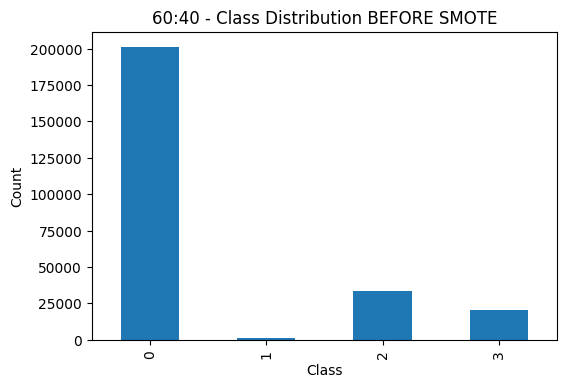

Train Distribution BEFORE SMOTE:
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


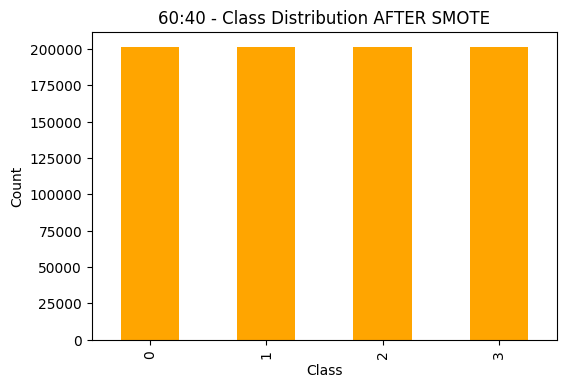

Train Distribution AFTER SMOTE:
0    201508
1    201439
2    201546
3    200949
Name: count, dtype: int64
Epoch 1: Loss=0.1705, TrainAcc=0.9391, TestAcc=0.9613, ROC-AUC=0.9985
Epoch 2: Loss=0.0635, TrainAcc=0.9792, TestAcc=0.9739, ROC-AUC=0.9993
Epoch 3: Loss=0.0457, TrainAcc=0.9850, TestAcc=0.9740, ROC-AUC=0.9992
Epoch 4: Loss=0.0355, TrainAcc=0.9886, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 5: Loss=0.0301, TrainAcc=0.9905, TestAcc=0.9802, ROC-AUC=0.9994
Epoch 6: Loss=0.0269, TrainAcc=0.9917, TestAcc=0.9823, ROC-AUC=0.9995
Epoch 7: Loss=0.0248, TrainAcc=0.9924, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 8: Loss=0.0228, TrainAcc=0.9929, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 9: Loss=0.0217, TrainAcc=0.9933, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 10: Loss=0.0208, TrainAcc=0.9935, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 11: Loss=0.0202, TrainAcc=0.9937, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 12: Loss=0.0196, TrainAcc=0.9939, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 13: Loss=0.0190, TrainAcc=0.9941, TestAcc=0.9

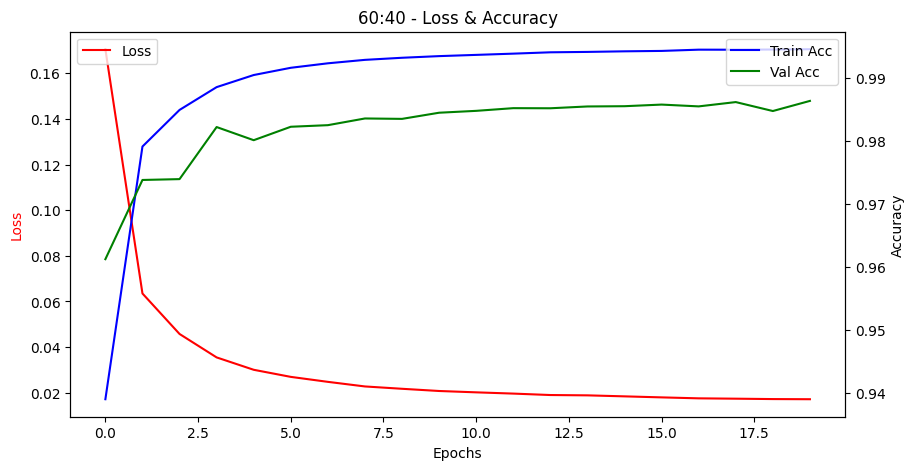

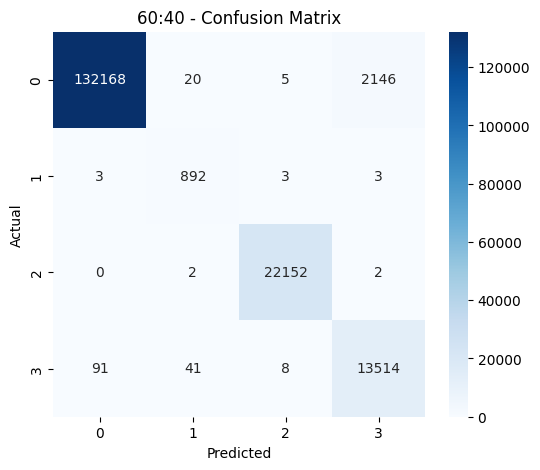


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.99      0.96       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.95      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



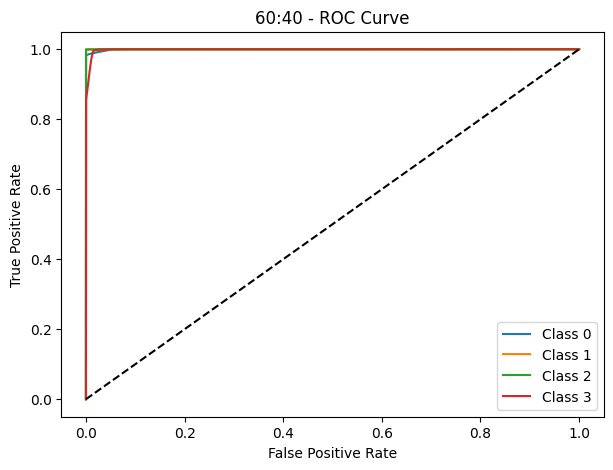

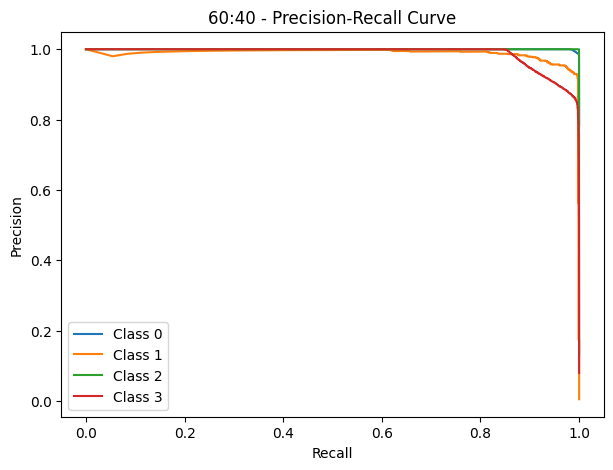


Runtime: 1217.93 seconds
RAM Used: 1233.83 MB

========== 70:30 ==========


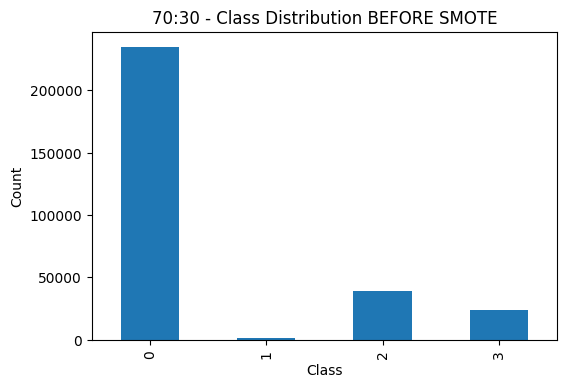

Train Distribution BEFORE SMOTE:
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


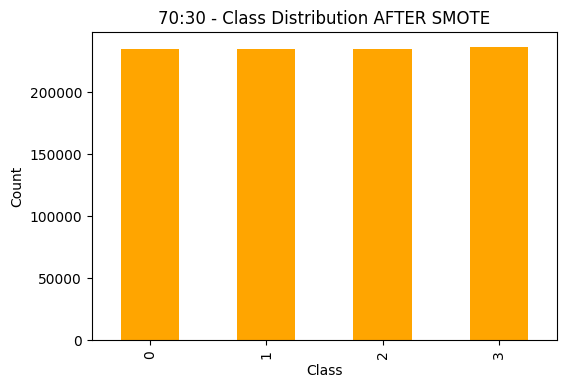

Train Distribution AFTER SMOTE:
0    235092
1    235149
2    235089
3    236755
Name: count, dtype: int64
Epoch 1: Loss=0.1768, TrainAcc=0.9368, TestAcc=0.9646, ROC-AUC=0.9987
Epoch 2: Loss=0.0604, TrainAcc=0.9804, TestAcc=0.9700, ROC-AUC=0.9987
Epoch 3: Loss=0.0412, TrainAcc=0.9869, TestAcc=0.9773, ROC-AUC=0.9993
Epoch 4: Loss=0.0328, TrainAcc=0.9896, TestAcc=0.9754, ROC-AUC=0.9991
Epoch 5: Loss=0.0284, TrainAcc=0.9912, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 6: Loss=0.0254, TrainAcc=0.9922, TestAcc=0.9835, ROC-AUC=0.9993
Epoch 7: Loss=0.0236, TrainAcc=0.9928, TestAcc=0.9827, ROC-AUC=0.9995
Epoch 8: Loss=0.0220, TrainAcc=0.9932, TestAcc=0.9818, ROC-AUC=0.9995
Epoch 9: Loss=0.0211, TrainAcc=0.9936, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 10: Loss=0.0206, TrainAcc=0.9937, TestAcc=0.9860, ROC-AUC=0.9995
Epoch 11: Loss=0.0197, TrainAcc=0.9940, TestAcc=0.9850, ROC-AUC=0.9996
Epoch 12: Loss=0.0191, TrainAcc=0.9942, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 13: Loss=0.0193, TrainAcc=0.9941, TestAcc=0.9

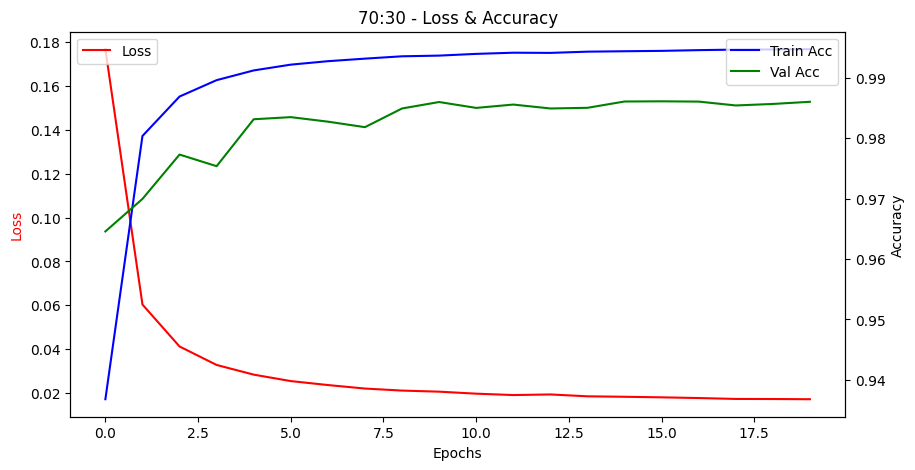

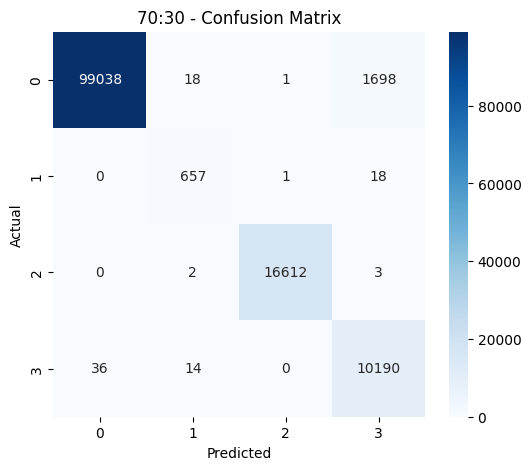


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.95      0.97      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.86      1.00      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



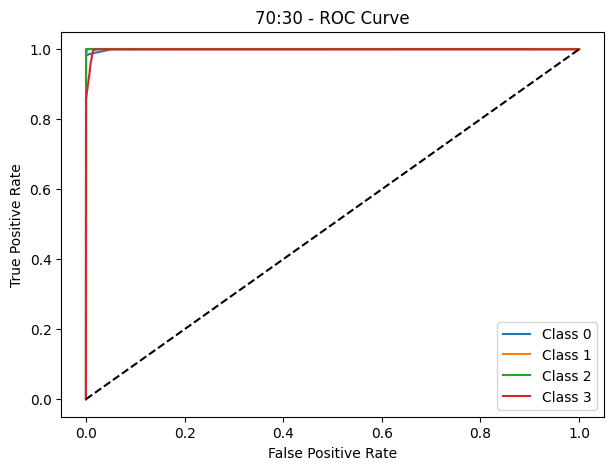

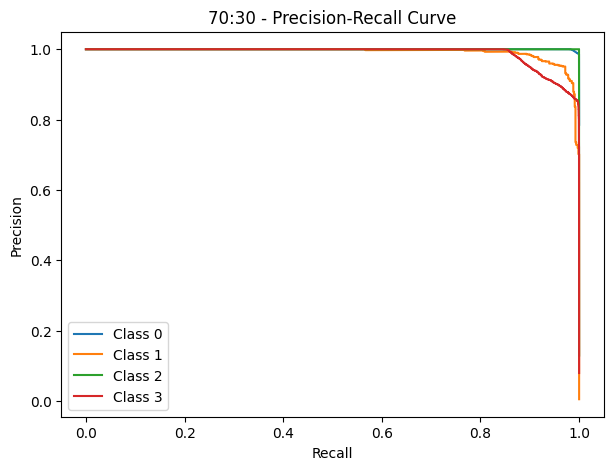


Runtime: 1376.53 seconds
RAM Used: 350.83 MB

========== 80:20 ==========


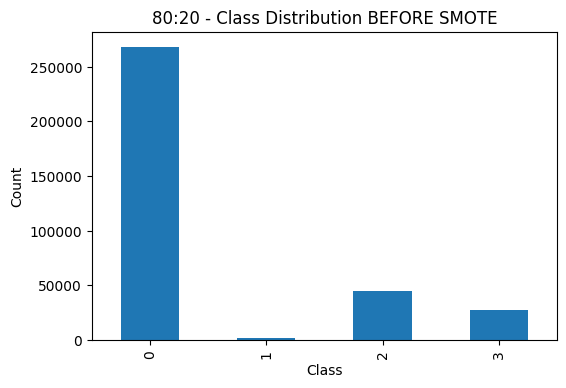

Train Distribution BEFORE SMOTE:
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


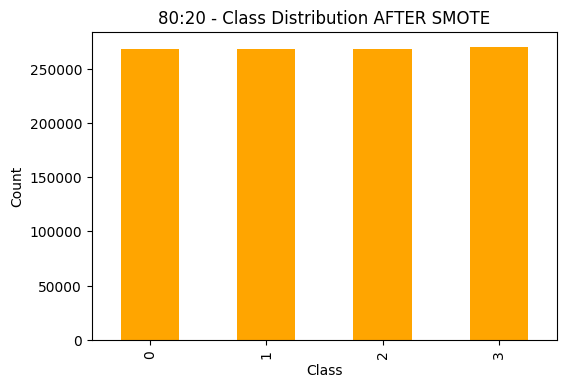

Train Distribution AFTER SMOTE:
0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64
Epoch 1: Loss=0.1446, TrainAcc=0.9482, TestAcc=0.9754, ROC-AUC=0.9988
Epoch 2: Loss=0.0465, TrainAcc=0.9854, TestAcc=0.9790, ROC-AUC=0.9990
Epoch 3: Loss=0.0335, TrainAcc=0.9898, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 4: Loss=0.0289, TrainAcc=0.9913, TestAcc=0.9832, ROC-AUC=0.9994
Epoch 5: Loss=0.0252, TrainAcc=0.9924, TestAcc=0.9847, ROC-AUC=0.9996
Epoch 6: Loss=0.0237, TrainAcc=0.9929, TestAcc=0.9815, ROC-AUC=0.9995
Epoch 7: Loss=0.0222, TrainAcc=0.9933, TestAcc=0.9713, ROC-AUC=0.9993
Epoch 8: Loss=0.0209, TrainAcc=0.9937, TestAcc=0.9861, ROC-AUC=0.9996
Epoch 9: Loss=0.0200, TrainAcc=0.9939, TestAcc=0.9866, ROC-AUC=0.9995
Epoch 10: Loss=0.0195, TrainAcc=0.9941, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 11: Loss=0.0190, TrainAcc=0.9942, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0185, TrainAcc=0.9944, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 13: Loss=0.0179, TrainAcc=0.9945, TestAcc=0.9

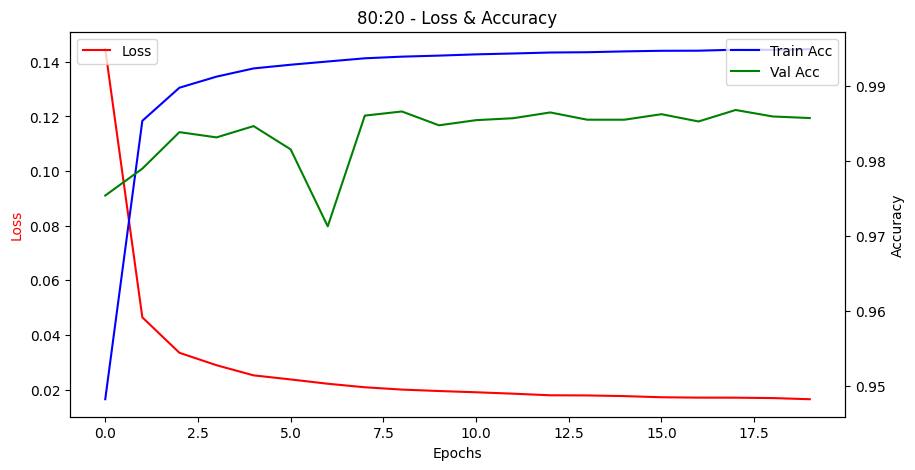

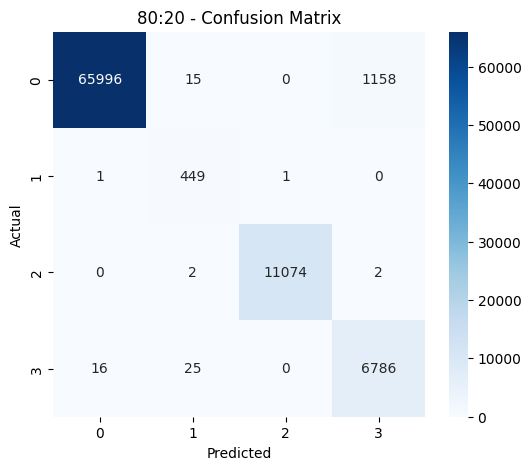


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.91      1.00      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



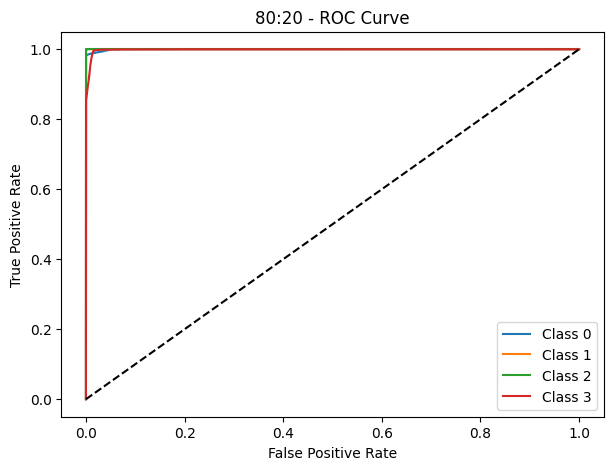

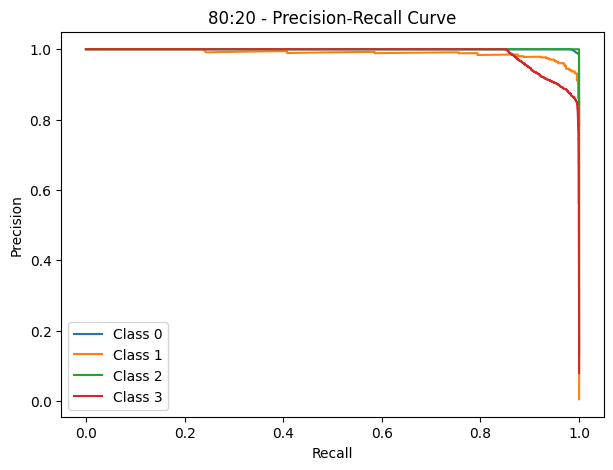


Runtime: 1566.03 seconds
RAM Used: 402.42 MB


In [10]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", 0.4)
run_split_adasyn(df, "70:30", 0.3)
run_split_adasyn(df, "80:20", 0.2)

# ADASYN + TomekLinks

In [11]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # ----------------- BEFORE SAMPLING -----------------
    print("\n📊 BEFORE ADASYN:")
    print(pd.Series(y_train).value_counts().sort_index())

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - BEFORE ADASYN")
    plt.show()

    # ----------------- ADASYN -----------------
    try:
        adasyn = ADASYN(random_state=42)
        X_train, y_train = adasyn.fit_resample(X_train, y_train)

        print("\n📊 AFTER ADASYN (FULL BALANCE):")
        print(pd.Series(y_train).value_counts().sort_index())

    except Exception as e:
        raise e

    # ----------------- TOMEK LINKS -----------------
    try:
        tomek = TomekLinks()
        X_train, y_train = tomek.fit_resample(X_train, y_train)

    except Exception as e:
        raise e

    # ----------------- AFTER SAMPLING -----------------
    print("\n📊 AFTER ADASYN + TOMEK:")
    print(pd.Series(y_train).value_counts().sort_index())
    print(f"New Training Shape: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - AFTER ADASYN + TOMEK")
    plt.show()

    # ----------------- SCALING -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=128, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=128)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    # recompute weights AFTER resampling
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACC -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} - Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(true, preds))

    # ----------------- ROC -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], 'k--')
    plt.legend()
    plt.title(f"{ratio_name} - ROC Curve")
    plt.show()

    # ----------------- PRECISION-RECALL -----------------
    plt.figure(figsize=(7,5))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} - Precision-Recall")
    plt.show()

    # ----------------- STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f} sec")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========

📊 BEFORE ADASYN:
0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64


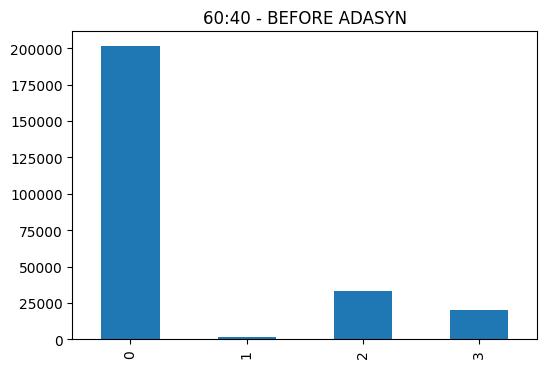


📊 AFTER ADASYN (FULL BALANCE):
0    201508
1    201439
2    201546
3    200949
Name: count, dtype: int64

📊 AFTER ADASYN + TOMEK:
0    197264
1    198377
2    199951
3    200949
Name: count, dtype: int64
New Training Shape: (796541, 24)


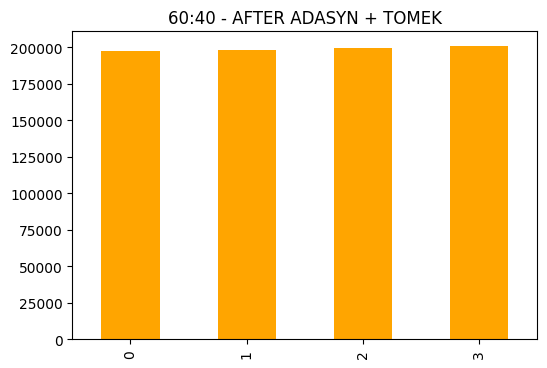

Epoch 1: Loss=0.2150, TrainAcc=0.9187, TestAcc=0.9582, ROC-AUC=0.9986
Epoch 2: Loss=0.0740, TrainAcc=0.9745, TestAcc=0.9679, ROC-AUC=0.9989
Epoch 3: Loss=0.0535, TrainAcc=0.9819, TestAcc=0.9702, ROC-AUC=0.9992
Epoch 4: Loss=0.0410, TrainAcc=0.9865, TestAcc=0.9730, ROC-AUC=0.9992
Epoch 5: Loss=0.0334, TrainAcc=0.9893, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 6: Loss=0.0291, TrainAcc=0.9908, TestAcc=0.9820, ROC-AUC=0.9994
Epoch 7: Loss=0.0261, TrainAcc=0.9920, TestAcc=0.9824, ROC-AUC=0.9993
Epoch 8: Loss=0.0241, TrainAcc=0.9925, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 9: Loss=0.0218, TrainAcc=0.9933, TestAcc=0.9845, ROC-AUC=0.9994
Epoch 10: Loss=0.0207, TrainAcc=0.9936, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 11: Loss=0.0199, TrainAcc=0.9939, TestAcc=0.9840, ROC-AUC=0.9994
Epoch 12: Loss=0.0193, TrainAcc=0.9941, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 13: Loss=0.0187, TrainAcc=0.9943, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 14: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 15: Loss=

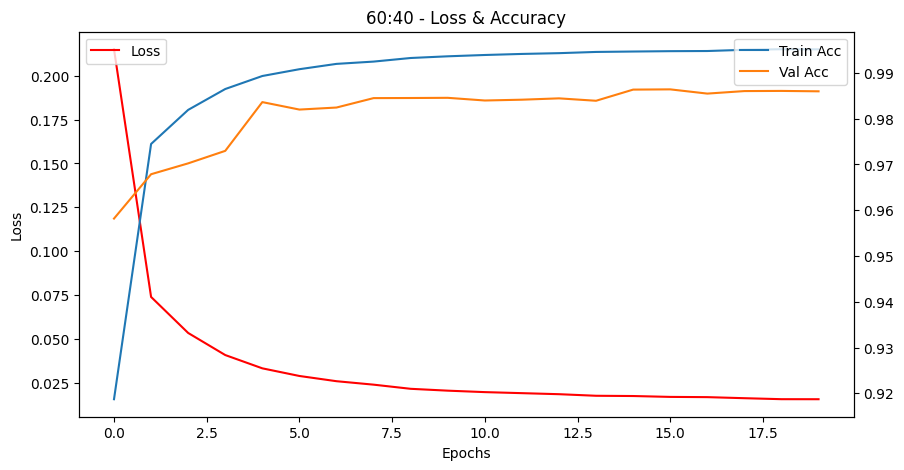

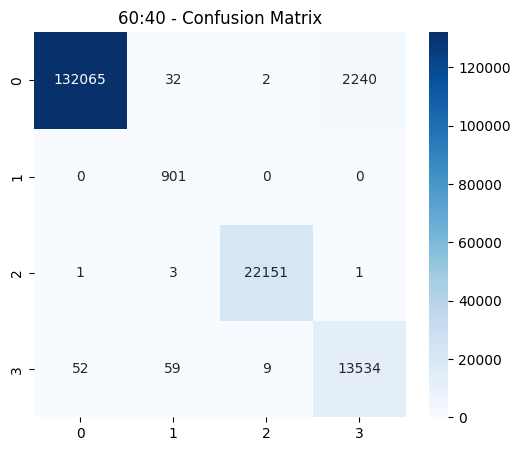


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.91      1.00      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



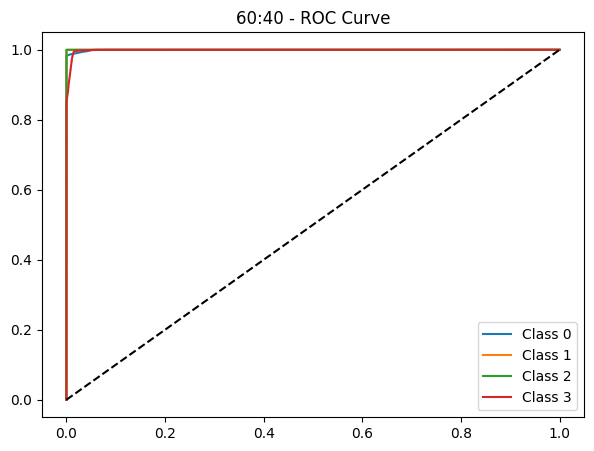

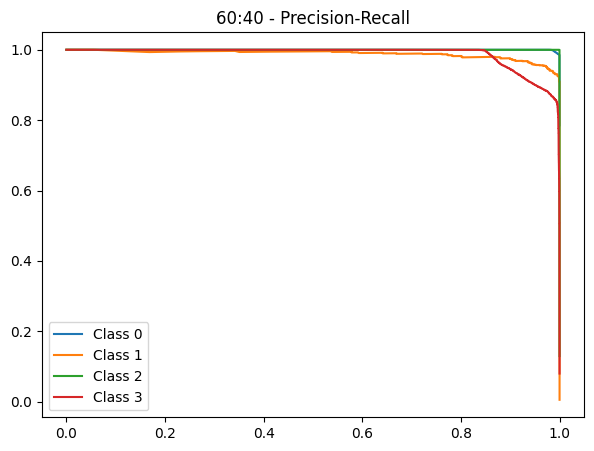


Runtime: 2249.92 sec
RAM Used: 323.93 MB

========== 70:30 ==========

📊 BEFORE ADASYN:
0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64


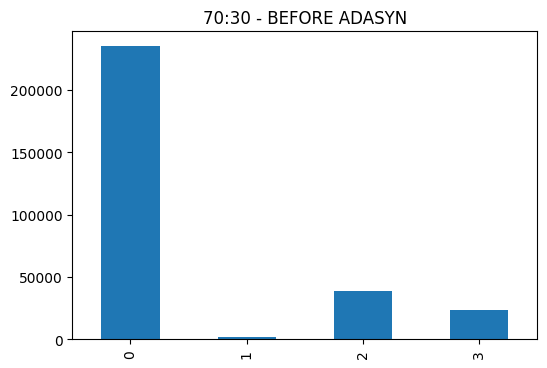


📊 AFTER ADASYN (FULL BALANCE):
0    235092
1    235149
2    235089
3    236755
Name: count, dtype: int64

📊 AFTER ADASYN + TOMEK:
0    230618
1    231924
2    235089
3    233504
Name: count, dtype: int64
New Training Shape: (931135, 24)


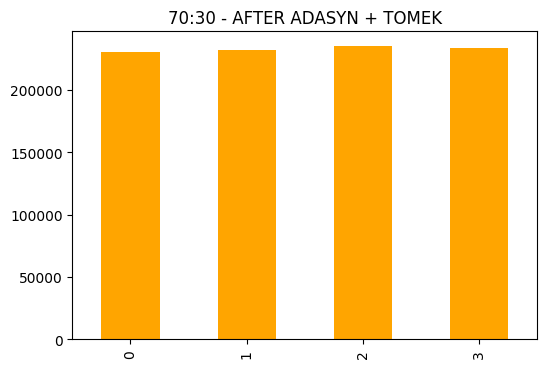

Epoch 1: Loss=0.1834, TrainAcc=0.9317, TestAcc=0.9723, ROC-AUC=0.9987
Epoch 2: Loss=0.0654, TrainAcc=0.9783, TestAcc=0.9710, ROC-AUC=0.9989
Epoch 3: Loss=0.0476, TrainAcc=0.9845, TestAcc=0.9777, ROC-AUC=0.9992
Epoch 4: Loss=0.0379, TrainAcc=0.9879, TestAcc=0.9806, ROC-AUC=0.9994
Epoch 5: Loss=0.0325, TrainAcc=0.9898, TestAcc=0.9813, ROC-AUC=0.9994
Epoch 6: Loss=0.0290, TrainAcc=0.9911, TestAcc=0.9771, ROC-AUC=0.9994
Epoch 7: Loss=0.0251, TrainAcc=0.9923, TestAcc=0.9832, ROC-AUC=0.9995
Epoch 8: Loss=0.0238, TrainAcc=0.9929, TestAcc=0.9831, ROC-AUC=0.9995
Epoch 9: Loss=0.0223, TrainAcc=0.9933, TestAcc=0.9766, ROC-AUC=0.9993
Epoch 10: Loss=0.0211, TrainAcc=0.9936, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 11: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 12: Loss=0.0194, TrainAcc=0.9941, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 13: Loss=0.0189, TrainAcc=0.9943, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 14: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 15: Loss=

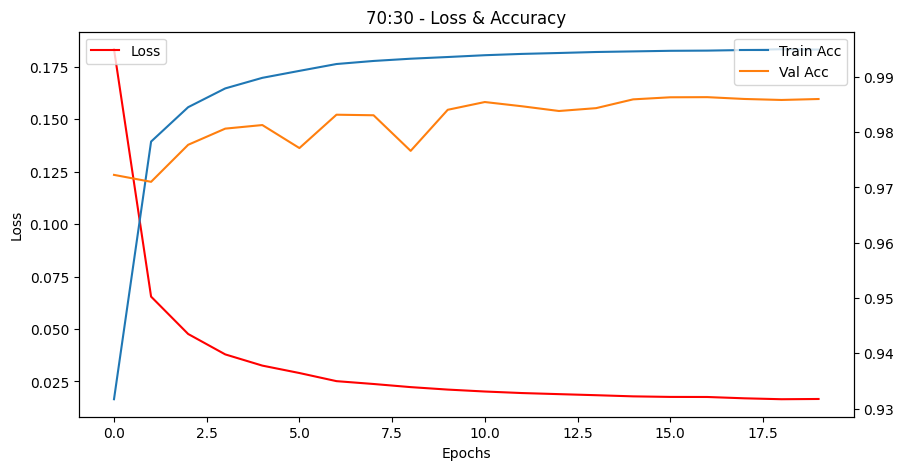

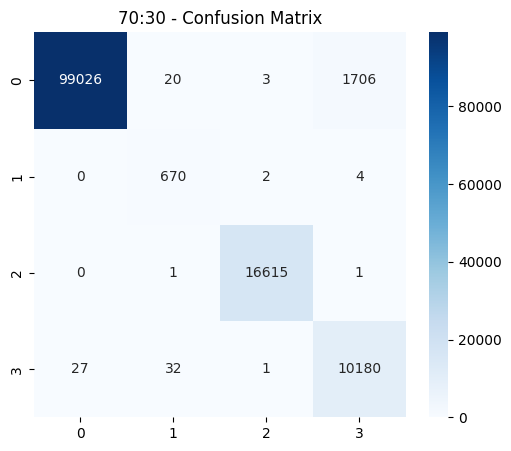


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.93      0.99      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



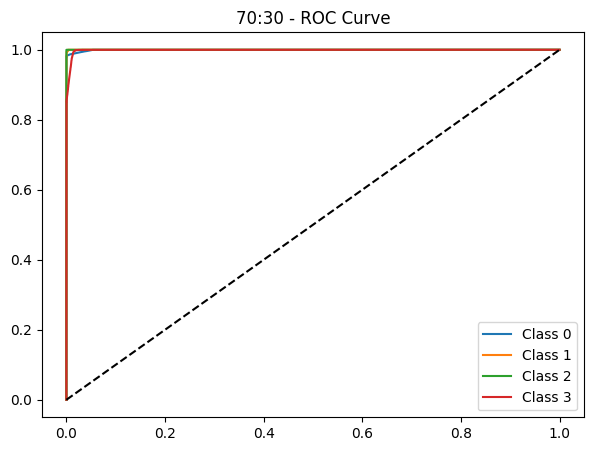

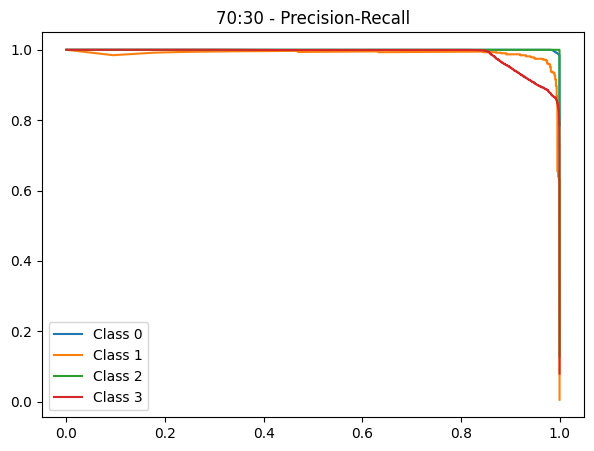


Runtime: 2958.15 sec
RAM Used: 336.71 MB

========== 80:20 ==========

📊 BEFORE ADASYN:
0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64


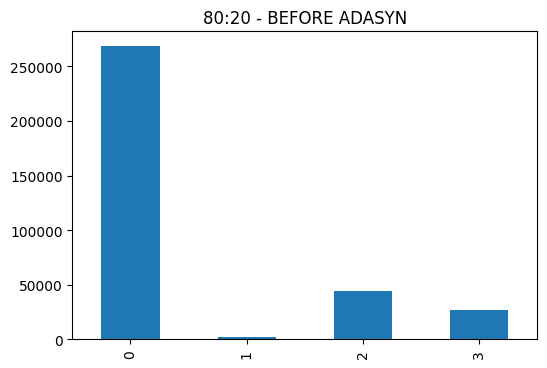


📊 AFTER ADASYN (FULL BALANCE):
0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64

📊 AFTER ADASYN + TOMEK:
0    264566
1    268367
2    267606
3    267605
Name: count, dtype: int64
New Training Shape: (1068144, 24)


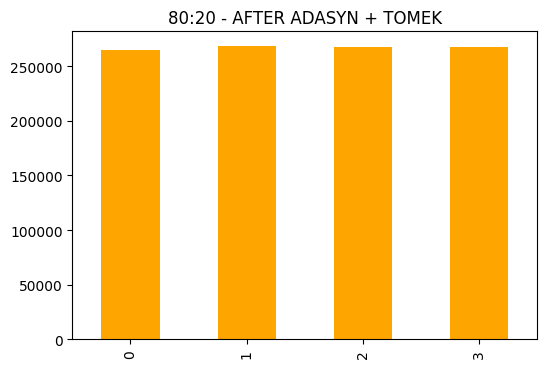

Epoch 1: Loss=0.1652, TrainAcc=0.9391, TestAcc=0.9756, ROC-AUC=0.9990
Epoch 2: Loss=0.0508, TrainAcc=0.9836, TestAcc=0.9766, ROC-AUC=0.9990
Epoch 3: Loss=0.0379, TrainAcc=0.9880, TestAcc=0.9810, ROC-AUC=0.9993
Epoch 4: Loss=0.0308, TrainAcc=0.9904, TestAcc=0.9671, ROC-AUC=0.9992
Epoch 5: Loss=0.0270, TrainAcc=0.9916, TestAcc=0.9835, ROC-AUC=0.9995
Epoch 6: Loss=0.0241, TrainAcc=0.9926, TestAcc=0.9829, ROC-AUC=0.9994
Epoch 7: Loss=0.0228, TrainAcc=0.9930, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 8: Loss=0.0213, TrainAcc=0.9935, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 9: Loss=0.0203, TrainAcc=0.9939, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 10: Loss=0.0192, TrainAcc=0.9942, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 11: Loss=0.0185, TrainAcc=0.9944, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 12: Loss=0.0181, TrainAcc=0.9945, TestAcc=0.9850, ROC-AUC=0.9996
Epoch 13: Loss=0.0176, TrainAcc=0.9947, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 14: Loss=0.0175, TrainAcc=0.9947, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 15: Loss=

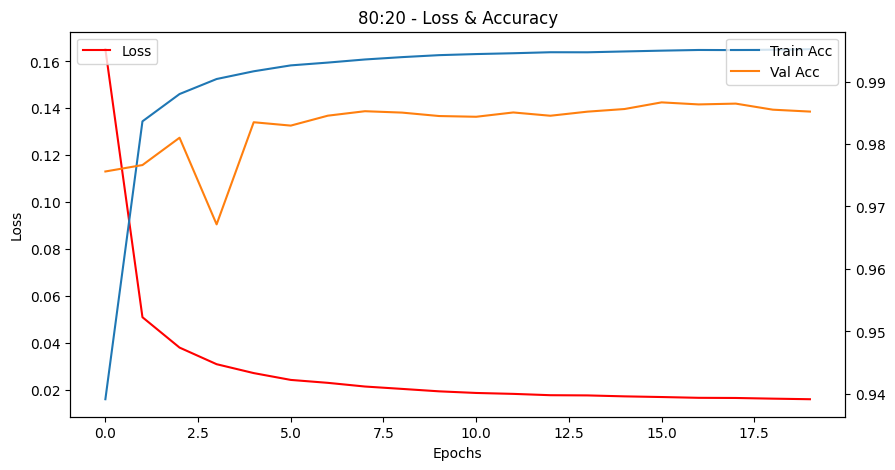

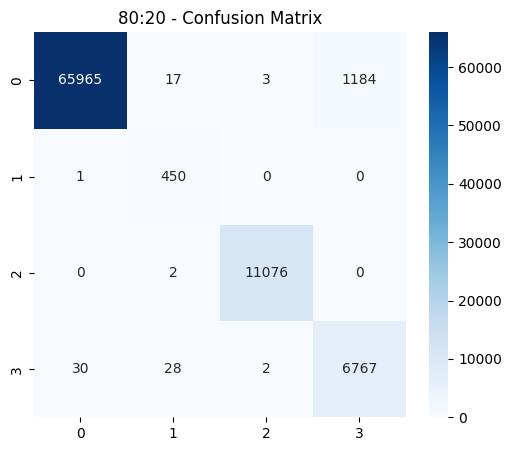


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.91      1.00      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



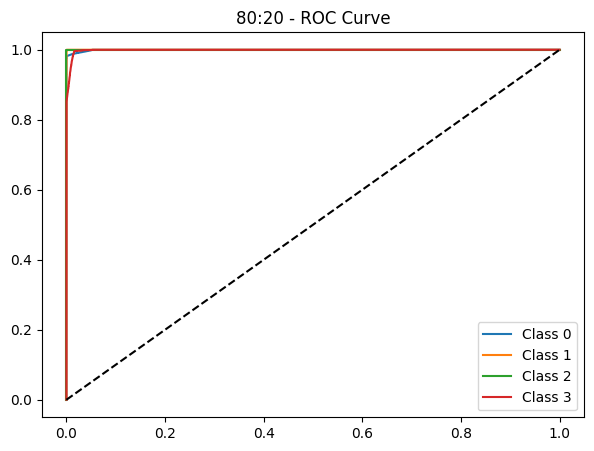

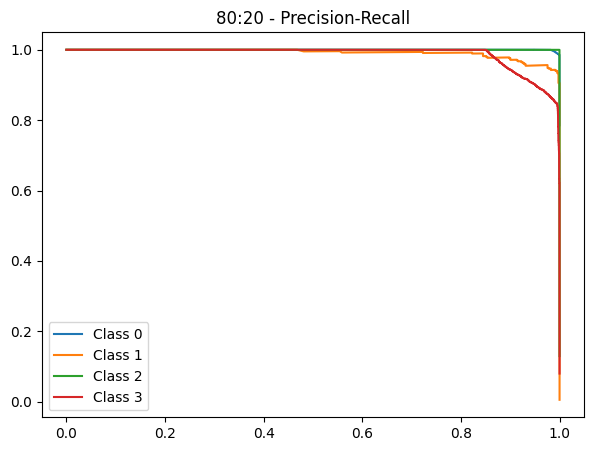


Runtime: 3734.38 sec
RAM Used: 375.68 MB


In [12]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", 0.4)
run_split_adasyn_tomek(df, "70:30", 0.3)
run_split_adasyn_tomek(df, "80:20", 0.2)